Data Understanding

In [3]:
import pandas as pd

df = pd.read_csv("Salary_dataset.csv")

df.head(10)

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0
5,5,3.0,56643.0
6,6,3.1,60151.0
7,7,3.3,54446.0
8,8,3.3,64446.0
9,9,3.8,57190.0


In [4]:
df.tail()

,Unnamed: 0,YearsExperience,Salary
25,25,9.1,105583.0
26,26,9.6,116970.0
27,27,9.7,112636.0
28,28,10.4,122392.0
29,29,10.6,121873.0


In [5]:
df.describe()

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


In [7]:
# Menampilkan data secara acak
df.sample(n=5)

,Unnamed: 0,YearsExperience,Salary
15,15,5.0,67939.0
11,11,4.1,55795.0
23,23,8.3,113813.0
20,20,6.9,91739.0
1,1,1.4,46206.0


In [8]:
# Memilih data baris 10 - 15
df.iloc[10:15]

,Unnamed: 0,YearsExperience,Salary
10,10,4.0,63219.0
11,11,4.1,55795.0
12,12,4.1,56958.0
13,13,4.2,57082.0
14,14,4.6,61112.0


Data Cleansing

In [9]:
df.isnull().sum()

Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64

In [10]:
df.drop_duplicates()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0
5,5,3.0,56643.0
6,6,3.1,60151.0
7,7,3.3,54446.0
8,8,3.3,64446.0
9,9,3.8,57190.0


In [11]:
# Mengubah tipe data dari float menjadi int

df["YearsExperience"] = df["YearsExperience"].astype(int)
df["Salary"] = df["Salary"].astype(int)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Unnamed: 0       30 non-null     int64
 1   YearsExperience  30 non-null     int64
 2   Salary           30 non-null     int64
dtypes: int64(3)
memory usage: 852.0 bytes


In [12]:
df.iloc[10:20]

,Unnamed: 0,YearsExperience,Salary
10,10,4,63219
11,11,4,55795
12,12,4,56958
13,13,4,57082
14,14,4,61112
15,15,5,67939
16,16,5,66030
17,17,5,83089
18,18,6,81364
19,19,6,93941


Visualisasi Data

<Axes: xlabel='YearsExperience'>

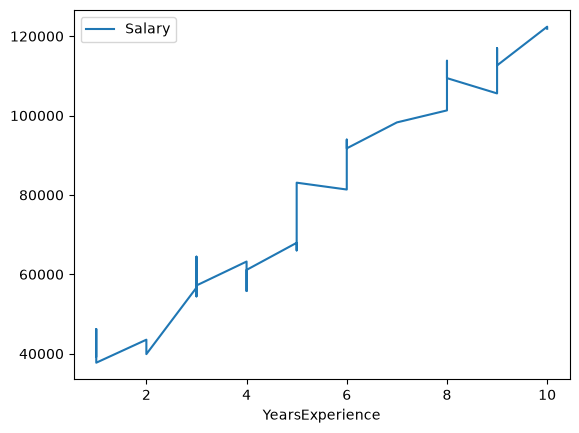

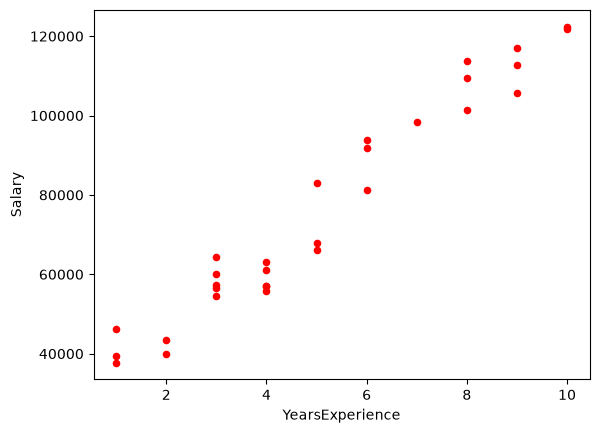

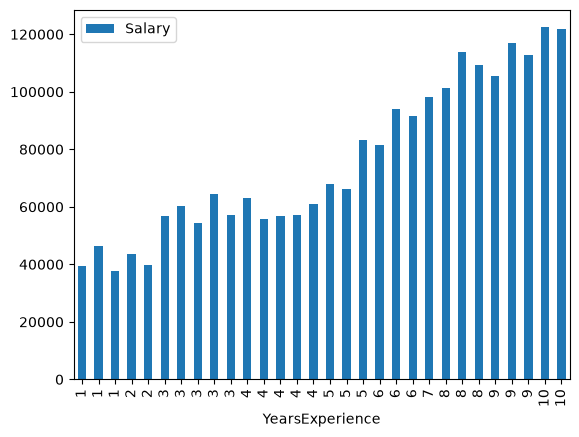

In [13]:
df.plot(x="YearsExperience", y="Salary")
df.plot.scatter(x="YearsExperience", y="Salary", color="red")
df.plot.bar(x="YearsExperience", y="Salary")

Visualisasi data dengan matplotlib

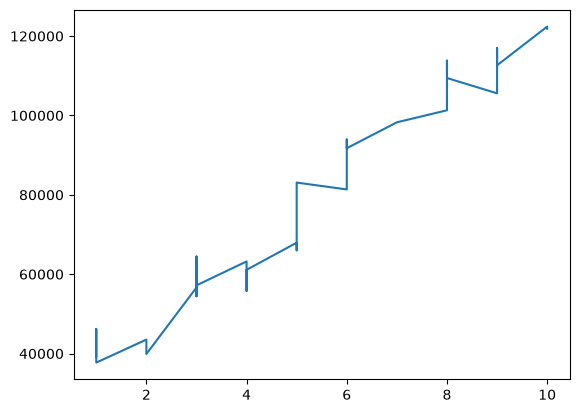

In [14]:
import matplotlib.pyplot as plt

a = df["YearsExperience"]
b = df["Salary"]

plt.plot(a, b)
plt.show()

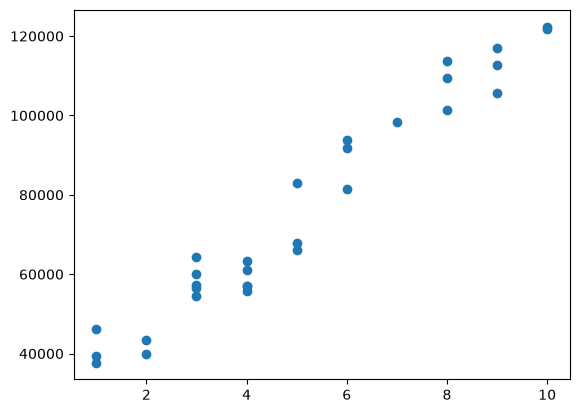

In [15]:
plt.scatter(a, b)
plt.show()

Melihat korelasi data

In [16]:
korelasi = df[["YearsExperience", "Salary"]].corr()
print(korelasi)

# semakin mendekati angka 1 semakin baik

                 YearsExperience    Salary
YearsExperience         1.000000  0.974983
Salary                  0.974983  1.000000


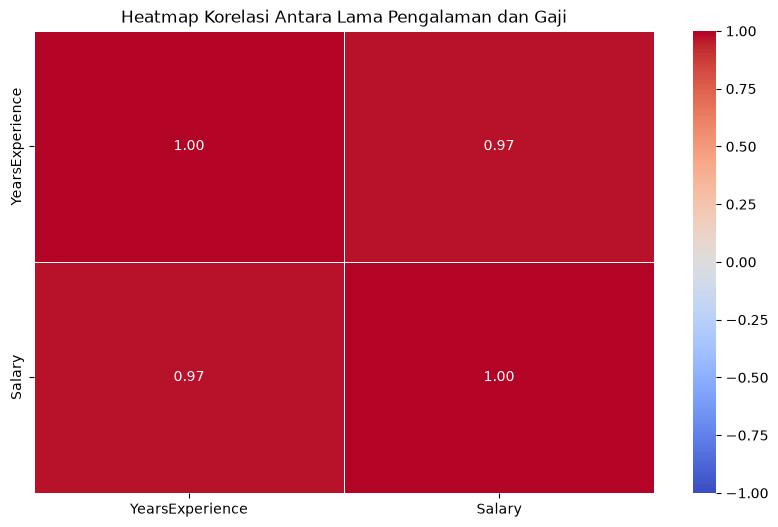

In [17]:
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.heatmap(
    korelasi,
    annot=True,        # Menampilkan nilai korelasi di dalam kotak
    cmap='coolwarm',   # Palet warna (merah=positif, biru=negatif)
    vmin=-1, vmax=1,   # Rentang nilai korelasi
    fmt=".2f",         # Format 2 angka di belakang koma
    linewidths=0.5     # Memberi garis pembatas antar kotak
)

plt.title("Heatmap Korelasi Antara Lama Pengalaman dan Gaji")
plt.show()

Data Preparation

In [18]:
X = df[["YearsExperience"]] # Kurung siku ganda untuk membuat dataframe berformat 2D
y = df["Salary"] # Kurung siku tunggal untuk membuat series
# scikit-learn memerlukan input fitur X berupa array 2 dimensi (2D).

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
# Train test split untuk membagi dataset
# test_size = 0.2 berarti membagi dataset menjadi 80% data latih dan 20% data uji
# random_state = 42 untuk memastikan hasil pembagian dataset terkunci sehingga tidak berubah-ubah setiap dijalankan

print(f"Data latih: {len(X_train)} baris")
print(f"Data uji  : {len(X_test)} baris")

Data latih: 24 baris
Data uji  : 6 baris


In [21]:
from sklearn.linear_model import LinearRegression

# inisialisasi dan fitting model

model = LinearRegression()
model.fit(X_train, y_train)

# Melihat parameter garis regresi linear (y = mx + c)
print("Kemiringan (m): ", model.coef_[0])
print("Titik potong (intercept c): ", model.intercept_)

Kemiringan (m):  9617.399999999998
Titik potong (intercept c):  26121.625000000015


In [ ]:
from sklearn.metrics import mean_ab